# MODELO KMEANS PARA CLASIFICACIÓN DE CLIENTES
## FUENTE : [KAGGLE](https://www.kaggle.com/datasets/dev0914sharma/customer-clustering?resource=download)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dev0914sharma/customer-clustering")

print("Path to dataset files:", path)

100%|██████████| 25.9k/25.9k [00:00<00:00, 25.2MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/dev0914sharma/customer-clustering/versions/1


In [ ]:
!ls /root/.cache/kagglehub/datasets/dev0914sharma/customer-clustering/versions/1

'segmentation data.csv'  'segmentation data legend.xlsx'


In [ ]:
PATH_CSV = path + '/segmentation data.csv'

In [ ]:
df = pd.read_csv(PATH_CSV)
df

,ID,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
0,100000001,0,0,67,2,124670,1,2
1,100000002,1,1,22,1,150773,1,2
2,100000003,0,0,49,1,89210,0,0
3,100000004,0,0,45,1,171565,1,1
4,100000005,0,0,53,1,149031,1,1
...,...,...,...,...,...,...,...,...
1995,100001996,1,0,47,1,123525,0,0
1996,100001997,1,1,27,1,117744,1,0
1997,100001998,0,0,31,0,86400,0,0
1998,100001999,1,1,24,1,97968,0,0


In [ ]:
df.dtypes

,0
ID,int64
Sex,int64
Marital status,int64
Age,int64
Education,int64
Income,int64
Occupation,int64
Settlement size,int64


In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
df.drop(columns=['ID'],inplace=True)
df.head(5)

,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
0,0,0,67,2,124670,1,2
1,1,1,22,1,150773,1,2
2,0,0,49,1,89210,0,0
3,0,0,45,1,171565,1,1
4,0,0,53,1,149031,1,1


# BUSCAMOS OUTLIERS


In [ ]:
from scipy.stats import zscore

z_scores = df.apply(zscore)

outliers = (z_scores.abs() > 3).sum()

outliers

,0
Sex,0
Marital status,0
Age,11
Education,36
Income,31
Occupation,0
Settlement size,0


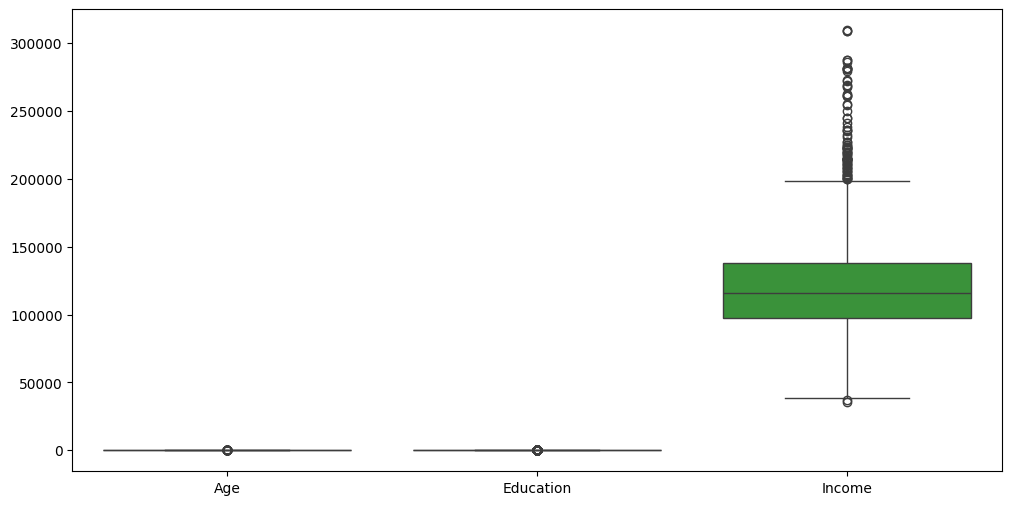

In [ ]:
plt.figure(figsize=(12,6))

sns.boxplot(data=df[['Age','Education','Income']])
plt.show()

In [ ]:
df_cleaned = df[
    (z_scores['Age'].abs() <= 3) &
    (z_scores['Education'].abs() <= 3) &
    (z_scores['Income'].abs() <= 3)
].copy()
df_cleaned

,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
0,0,0,67,2,124670,1,2
1,1,1,22,1,150773,1,2
2,0,0,49,1,89210,0,0
3,0,0,45,1,171565,1,1
4,0,0,53,1,149031,1,1
...,...,...,...,...,...,...,...
1995,1,0,47,1,123525,0,0
1996,1,1,27,1,117744,1,0
1997,0,0,31,0,86400,0,0
1998,1,1,24,1,97968,0,0


# APLICAMOS DBSCAN